In [ ]:

!pip install -U "jax[cuda12_pip]" -f https://storage.googleapis.com/jax-releases/jax_cuda_releases.html



Cloning into 'dreamerv3'...
remote: Enumerating objects: 530, done.
remote: Total 530 (delta 0), reused 0 (delta 0), pack-reused 530 (from 1)
Receiving objects: 100% (530/530), 26.28 MiB | 42.11 MiB/s, done.
Resolving deltas: 100% (232/232), done.
Looking in links: https://storage.googleapis.com/jax-releases/jax_cuda_releases.html
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 MB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 73.3 MB/s eta 0:00:00
  Attempting uninstall: jaxlib
    Found existing installation: jaxlib 0.7.2
    Uninstalling jaxlib-0.7.2:
      Successfully uninstalled jaxlib-0.7.2
  Attempting uninstall: jax
    Found existing installation: jax 0.7.2
    Uninstalling jax-0.7.2:
      Successfully uninstalled jax-0.7.2


In [ ]:
!pip install -U -r dreamerv3/requirements.txt

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 49.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 434.7/434.7 kB 45.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
INFO: pip is looking at multiple versions of chex to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of optax to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 81.2 MB/s eta 0:00:00
   ━━━━━━━━

In [ ]:
!pip install crafter

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.6/107.6 kB 10.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.0/268.0 kB 26.1 MB/s eta 0:00:00
  Created wheel for crafter: filename=crafter-1.8.3-py3-none-any.whl size=143999 sha256=16018be18f0c1c59836f57408109dae2c07a77a4b8965cd5c9866fc971bc8f71
  Stored in directory: /root/.cache/pip/wheels/2a/03/67/55cb8a55d98466fa8d880cfa81197ba78ed5a4acc0cf1f6543
Successfully built crafter


In [ ]:
!python dreamerv3/dreamerv3/main.py \
  --logdir ~/logdir/dreamer_crafter \
  --configs crafter \
  --run.train_ratio 32
!--configs batch_size 32


In [ ]:
!python dreamerv3/dreamerv3/main.py \
  --logdir ~/logdir/dreamer_crafter \
  --configs crafter \
  --run.train_ratio 32
!--configs batch_length 128


In [ ]:
!python dreamerv3/dreamerv3/main.py \
  --logdir ~/logdir/dreamer_crafter \
  --configs crafter \
  --run.train_ratio 32
!--configs crafter size50m


---  ___                           __   ______ ---
--- |   \ _ _ ___ __ _ _ __  ___ _ \ \ / /__ / ---
--- | |) | '_/ -_) _` | '  \/ -_) '/\ V / |_ \ ---
--- |___/|_| \___\__,_|_|_|_\___|_|  \_/ |___/ ---
Replica: 0 / 1
Logdir: /content/logdir/dreamer_crafter
Run script: train
Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
Observations
  image            Space(uint8, shape=(64, 64, 3), low=0, high=255)
  reward           Space(float32, shape=(), low=-inf, high=inf)
  is_first         Space(bool, shape=(), low=False, high=True)
  is_last          Space(bool, shape=(), low=False, high=True)
  is_terminal      Space(bool, shape=(), low=False, high=True)
Actions
  action          

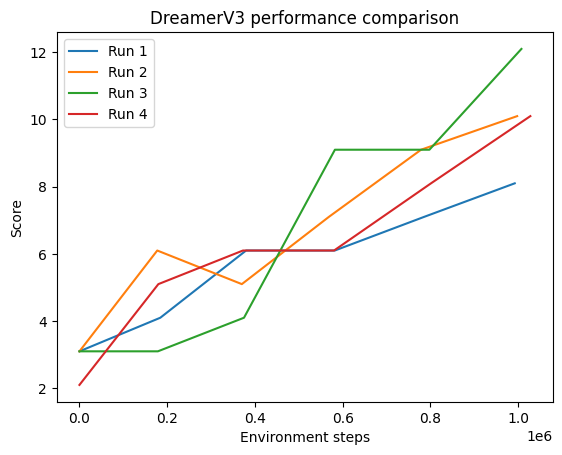

In [3]:
#view results in ablation_results
import json
import matplotlib.pyplot as plt

candidate_keys = ["crafter_score", "episode/score", "score"]

def load_metrics(path):
    steps, vals = [], []
    with open(path) as f:
        for line in f:
            d = json.loads(line)
            step = d.get("step")
            if step is None:
                continue
            for key in candidate_keys:
                if key in d:
                    steps.append(step)
                    vals.append(d[key])
                    break
    return steps, vals

# First file
steps1, vals1 = load_metrics("ablation_results/metrics.jsonl")

# Second file
steps2, vals2 = load_metrics("ablation_results/metrics (1).jsonl")

steps3, vals3 = load_metrics("ablation_results/metrics (2).jsonl")
steps4, vals4 = load_metrics("ablation_results/metrics (3).jsonl")
# print(vals3==vals4)
# plt.plot(steps1, vals1, label="Run 1")
# plt.plot(steps2, vals2, label="Run 2")
# plt.plot(steps3, vals3, label="Run 3")
# plt.plot(steps4, vals4, label="Run 4")
steps1_sub = steps1[::1000]
vals1_sub = vals1[::1000]

plt.plot(steps1_sub, vals1_sub, label="Run 1")
steps2_sub = steps2[::1000]
vals2_sub = vals2[::1000]

plt.plot(steps2_sub, vals2_sub, label="Run 2")

steps3_sub = steps3[::1000]
vals3_sub = vals3[::1000]
plt.plot(steps3_sub, vals3_sub, label="Run 3")

steps4_sub = steps4[::1000]
vals4_sub = vals4[::1000]
plt.plot(steps4_sub, vals4_sub, label="Run 4")
# steps1_sub = steps1[::100]
# vals1_sub = vals1[::100]

# plt.plot(steps1_sub, vals1_sub, label="Run 1")
# steps2_sub = steps2[::100]
# vals2_sub = vals2[::100]

# plt.plot(steps2_sub, vals2_sub, label="Run 2")

# steps3_sub = steps3[::100]
# vals3_sub = vals3[::100]
# plt.plot(steps3_sub, vals3_sub, label="Run 3")

# steps4_sub = steps4[::100]
# vals4_sub = vals4[::100]
# plt.plot(steps4_sub, vals4_sub, label="Run 4")
# print(vals3_sub==vals4_sub)
plt.xlabel("Environment steps")
plt.ylabel("Score")
plt.title("DreamerV3 performance comparison")
plt.legend()
plt.show()


In [ ]:
#view results of new run
steps, vals= load_metrics("~/logdir/dreamer_crafter/metrics.jsonl")
steps_sub = steps[::1000]
vals_sub = vals[::1000]

plt.plot(steps_sub, vals_sub, label="Run 1")